# Análise de resultados de combinações de modelos sobre os dados de teste

## 1. Sobre as bases originais

Os testes foram realizados usando de 3 bases distintos por tamanho, quantidade e tipos de problemas diferentes presentes.

In [16]:
import pandas as pd

In [17]:
dummy_dataset = pd.read_csv("../data/test_data.csv")
car_dataset =  pd.read_csv("../data/car_price.csv")
movies_dataset =  pd.read_csv("../data/movieRatingsMid2026.csv")

### 1.1 Dummy dataset

In [18]:
dummy_dataset.shape, dummy_dataset.dtypes

((7, 7),
 Loja                 str
 data_abertura        str
 classe               str
 metragem         float64
 faturamento        int64
 qt_mesas           int64
 especial             str
 dtype: object)

In [19]:
dummy_dataset

,Loja,data_abertura,classe,metragem,faturamento,qt_mesas,especial
0,'Loja A','20/01/2023','Popular',50.0,1000000,5,'Sim'
1,'Loja B','07/04/2020','Premium',62.0,1500000,7,'Sim'
2,'Loja C','01/01/2023','Mista',43.0,1200000,6,'Não'
3,'Loja D','01/01/2024','Genérica',45.0,900000,4,'Não'
4,'Loja E','07/05/2024','Mista',45.0,1000000,4,NaN
5,'Loja F','18/04/2024','Mista',50.0,1050000,4,NaN
6,'Loja G','10/04/2024','Premium',NaN,1150000,4,'Sim'


A base *dummy_dataset* é bem pequena com apenas 7 linhas e 7 colunas. Alguns dos problemas iniciais identificados nela são:
- Coluna *data_abertura* em formato string sendo que deveria estar no formato *datetime*
- Coluna *classe* sendo uma coluna categórica mas não estar em um formato numérico que possa ser consumido por um modelo de regressão.
- Coluna *metragem* com um valor nulo
- Coluna *especial* com valores nulos e também não está em formato numérico, por exemplo, binário.

### 1.2 Movies dataset

In [20]:
movies_dataset.shape, movies_dataset.dtypes, movies_dataset.isna().sum()

((103, 18),
 ID                       int64
 Movie                      str
 Watch Date                 str
 Year                     int64
 Type 1                     str
 Type 2                     str
 Animation                int64
 Origin Country             str
 Friend Who chose it    float64
 Did Friend 5 sleep     float64
 Duration (minutes)       int64
 Friend 2 score         float64
 Friend 5 score         float64
 Friend 7 score         float64
 Friend 8 score         float64
 Mean score                 str
 IMDB score                 str
 IMDB-Mean                  str
 dtype: object,
 ID                      0
 Movie                   0
 Watch Date              0
 Year                    0
 Type 1                  0
 Type 2                  1
 Animation               0
 Origin Country          0
 Friend Who chose it    15
 Did Friend 5 sleep     10
 Duration (minutes)      0
 Friend 2 score          4
 Friend 5 score          7
 Friend 7 score          9
 Friend 8 score   

In [21]:
movies_dataset.head()

,ID,Movie,Watch Date,Year,Type 1,Type 2,Animation,Origin Country,Friend Who chose it,Did Friend 5 sleep,Duration (minutes),Friend 2 score,Friend 5 score,Friend 7 score,Friend 8 score,Mean score,IMDB score,IMDB-Mean
0,1,Elite Squad,09/09/2021,2007,Action,Crime,0,Brazil,3.0,1.0,115,8.0,9.0,9.0,9.0,"8,75",8,"-0,75"
1,2,The Forever Purge,16/09/2021,2021,Action,Horror,0,USA,1.0,0.0,104,2.0,2.0,2.0,2.0,"2,00","5,4","3,40"
2,3,Forrest Gump,23/09/2021,1994,Drama,Romance,0,USA,2.0,0.0,142,10.0,9.0,9.0,10.0,"9,50","8,8","-0,70"
3,4,The Orphanage,30/09/2021,2007,Horror,Thriller,0,Spain,5.0,0.0,105,8.0,8.0,7.0,7.0,"7,50","7,4","-0,10"
4,5,Rubber,07/10/2021,2010,Horror,Comedy,0,France,6.0,0.0,85,4.0,4.0,4.0,10.0,"5,50","5,7","0,20"


O dataset de notas de filmes possui 103 linhas e 18 colunas. Alguns dos problemas que podem ser identificados na base são:
- A coluna *Watch Date* está no formato *string* sendo que ela poderia estar no formato *datetime*
- As colunas *Type 1*, *Type 2* e *Origin Country* são categóricas e, portanto, poderia ser aplicado algum tipo de *encoding* nos seus valores via *one-hot* ou mapeamentos dentro das próprias colunas
- A coluna *Type 2* possui um valor nulo
- As colunas *Mean score*, *IMDB score* e *IMDB-Mean* estão formatadas de forma a serem consideradas *string* ao invés de numéricas

### 1.3 Dataset de preços de carros

In [22]:
car_dataset.shape, car_dataset.dtypes, car_dataset.isna().sum()

((5512, 10),
 Unnamed: 0             int64
 car_name                 str
 car_prices_in_rupee      str
 kms_driven               str
 fuel_type                str
 transmission             str
 ownership                str
 manufacture            int64
 engine                   str
 Seats                    str
 dtype: object,
 Unnamed: 0             0
 car_name               0
 car_prices_in_rupee    0
 kms_driven             0
 fuel_type              0
 transmission           0
 ownership              0
 manufacture            0
 engine                 0
 Seats                  0
 dtype: int64)

In [23]:
car_dataset.head()

,Unnamed: 0,car_name,car_prices_in_rupee,kms_driven,fuel_type,transmission,ownership,manufacture,engine,Seats
0,0,Jeep Compass 2.0 Longitude Option BSIV,10.03 Lakh,"86,226 kms",Diesel,Manual,1st Owner,2017,1956 cc,5 Seats
1,1,Renault Duster RXZ Turbo CVT,12.83 Lakh,"13,248 kms",Petrol,Automatic,1st Owner,2021,1330 cc,5 Seats
2,2,Toyota Camry 2.5 G,16.40 Lakh,"60,343 kms",Petrol,Automatic,1st Owner,2016,2494 cc,5 Seats
3,3,Honda Jazz VX CVT,7.77 Lakh,"26,696 kms",Petrol,Automatic,1st Owner,2018,1199 cc,5 Seats
4,4,Volkswagen Polo 1.2 MPI Highline,5.15 Lakh,"69,414 kms",Petrol,Manual,1st Owner,2016,1199 cc,5 Seats


O dataset de preços de carros possui 5512 linhas e 10 colunas. Alguns dos problemas que ela possui, são:
- As colunas *fuel_type*, *transmission* e *ownership* são categóricas e se beneficiariam da aplicação de *encoding* em seus valores
- As colunas *car_prices_in_rupee*, *kms_driven*, *engine* e *Seats* possuem sufixos que as tornam do tipo *string* ao invés de numéricas. Em especial, a coluna *car_prices_in_rupee* possui dois sufixos diferentes: *Lakh* e *Crore*. O primeiro é uma unidade de medida a cada 100 mil rúpias, o segundo indica 10 milhões de rúpias.

De acordo com essas análises de problemas iniciais, é esperado que um agente de *data-readiness* seja capaz de lidar com todos eles para adequar as bases para análises posteriores e aplicações de técnicas de *machine learning*. 

## 2. Correções esperadas por base

Cada base de teste possui seu próprio conjunto de melhorias que são esperadas a serem feitas pelo agente. Tais melhorias foram definidas baseado na minha experiência como cientista de dados para uso posterior em análises e aplicação de modelos de *machine learning*. As condições de avaliação são divididas entre:
1) Tipos de dados
2) Presença de dados nulos
3) Cardinalidade de colunas
4) Intervalo numérico
5) Ações recomendadas pelo agente de avaliação
6) Severidade dos problemas encontrados na coluna

Nessa seção, são explicitadas as condições esperadas de cada base ao final de seu processamento pelo agente.

### 2.1 Expectativas na análise do agente de avaliação

A seguir, são indicadas as expectativas de severidade de problemas encontrados e ações recomendadas por coluna na base pelo agente de avaliação:
| Base      | Coluna              | Severidade    | Ações                                      |
|-----------|---------------------|---------------|--------------------------------------------|
| dummy     | metragem            |   Média       | Imputar valores nulos                      |
| dummy     | classe              | Baixa         | Aplicar *encoding*                         |
| dummy     | especial            |  Média        | Imputar valores nulos e aplicar *encoding* |
| dummy     | data_abertura       |  Média        | Converter tipo de coluna                   |
| dummy     | faturamento         | Sem problemas |                                            |
| dummy     | qt_mesas            | Sem problemas |                                            |
| dummy     | Loja                | Sem problemas |                                            |
| movies    | ID                  | Baixa         | Remover coluna                             |
| movies    | Movie               | Sem problemas |                                            |
| movies    | Watch Date          |  Média        | Converter tipo para datetime               |
| movies    | Year                | Baixa         | Criar coluna derivada de 'idade'           |
| movies    | Type 1              |  Média        | Aplicar *encoding*                         |
| movies    | Type 2              |  Média        | Imputar valores nulos e aplicar *encoding* |
| movies    | Animation           | Sem problemas |                                            |
| movies    | Origin Country      |   Média       | Aplicar *encoding*                         |
| movies    | Mean score          | Alta          |  Converter tipo para numérico              |
| movies    | IMDB score          | Alta          |  Converter tipo para numérico              |
| movies    | IMDB-Mean           | Alta          |  Converter tipo para numérico              |
| movies    | Did Friend 5 sleep  |   Média       |                                            |
| movies    | Duration (minutes)  | Sem problemas |                                            |
| movies    | Friend 2 score      | Baixa         |                                            |
| movies    | Friend 5 score      | Baixa         |                                            |
| movies    | Friend 7 score      | Baixa         |                                            |
| movies    | Friend 8 score      | Baixa         |                                            |
| car_price | Unnamed: 0          | Baixa         | Remover coluna                             |
| car_price | car_name            | Sem problemas |                                            |
| car_price | car_prices_in_rupee | Alta          |  Converter tipo para numérico              |
| car_price | kms_driven          | Alta          |  Converter tipo para numérico              |
| car_price | fuel_type           |  Média        | Aplicar *encoding*                         |
| car_price | transmission        |  Média        | Aplicar *encoding*                         |
| car_price | ownership           |  Média        | Aplicar *encoding*                         |
| car_price | manufacture         | Sem problemas |                                            |
| car_price | engine              | Alta          |  Converter tipo para numérico              |
| car_price | Seats               | Alta          |  Converter tipo para numérico              |

### 2.2 Expectativas após aplicar o agente de transformação

A seguir, são indicadas as expectativas sobre o estado das colunas das bases após aplicar as transformações:

| Base      | Coluna              | Tipo      | Não ter nulos | Cardinalidade |  Range numérico   |
|-----------|---------------------|-----------|---------------|---------------|-------------------|
| dummy     | metragem            |  Numérico | Sim           |               | [43, 62]          |
| dummy     | classe              | Numérico  |               | 4             |                   |
| dummy     | especial            | Numérico  | Sim           | 3             |                   |
| dummy     | data_abertura       | datetime  |               |               |                   |
| dummy     | faturamento         | Numérico  |               |               |                   |
| dummy     | qt_mesas            | Numérico  |               |               | [4, 7]            |
| dummy     | Loja                | string    |               |               |                   |
| movies    | ID                  |           |               |               |                   |
| movies    | Movie               | string    |               |               |                   |
| movies    | Watch Date          | datetime  |               |               |                   |
| movies    | Year                | Numérico  | Sim           |               | [1975, 2026]      |
| movies    | Type 1              | Numérico  | Sim           |               |                   |
| movies    | Type 2              | Numérico  | Sim           |               |                   |
| movies    | Animation           | Numérico  | Sim           |               | [0, 1]            |
| movies    | Origin Country      | Numérico  | Sim           | 11            |                   |
| movies    | Mean score          | Numérico  | Sim           |               | [0, 10]           |
| movies    | IMDB score          | Numérico  | Sim           |               | [0, 10]           |
| movies    | IMDB-Mean           | Numérico  | Sim           |               |                   |
| movies    | Friend who chose it | Numérico  | Sim           |               | [1, 8]            |
| movies    | Did Friend 5 sleep  | Numérico  | Sim           |               |                   |
| movies    | Duration (minutes)  | Numérico  | Sim           |               | [66, 176]         |
| movies    | Friend 2 score      | Numérico  | Sim           |               |                   |
| movies    | Friend 5 score      | Numérico  | Sim           |               |                   |
| movies    | Friend 7 score      | Numérico  | Sim           |               |                   |
| movies    | Friend 8 score      | Numérico  | Sim           |               |                   |
| car_price | Unnamed: 0          | Numérico  |               |               |                   |
| car_price | car_name            | string    |               |               |                   |
| car_price | car_prices_in_rupee | Numérico  | Sim           |               | [35000, 19200000] |
| car_price | kms_driven          | Numérico  | Sim           |               | [250, 560000]     |
| car_price | fuel_type           | Numérico  | Sim           | 5             |                   |
| car_price | transmission        | Numérico  | Sim           | 2             |                   |
| car_price | ownership           | Numérico  | Sim           | 6             |                   |
| car_price | manufacture         | Numérico  | Sim           |               |                   |
| car_price | engine              | Numérico  | Sim           |               |                   |
| car_price | Seats               | Numérico  | Sim           |               | [2, 8]            |

## 3. Configurações dos experimentos

Para avaliar o agente, foram variadas as combinações de modelos usados nas etapas de avaliação e transformação da base original. As configurações testadas foram:

| ID |   Modelo agente avaliação |  Modelo agente transformação |
|----|---------------------------|------------------------------|
| 1  | gpt-4.1-nano              | gpt-4.1-nano                 |
| 2  | gpt-4o-mini               | gpt-4.1-nano                 |
| 3  | gpt-4o-mini               | gpt-4o-mini                  |
| 4  | gpt-5-mini                | gpt-4o-mini                  |
| 5  | gpt-5-mini                | gpt-5-mini                   |
| 6  | gpt-5-nano                | gpt-5-mini                   |
| 7  | gpt-5-nano                | gpt-5-nano                   |
| 8  | gpt-4.1-nano              | gpt-5-nano                   |

Essa configuração permite avaliar o uso de modelos distintos e de capacidades diferentes trabalhando em conjunto ou de forma exclusiva. Por exemplo, as configurações 1, 3, 4, e 7 são formadas, de forma exclusiva, por apenas um modelo. Já as outras combinam modelos de capacidades (e custos) diferentes.  

Para cada configuração, foram executadas 4 runs como forma de avaliar a variabilidade dos resultados. Essa quantidade baixa de runs foi definida de forma a não se gastar muito ao final dos experimentos. Em outro contexto, poderíamos aumentar a quantidade de runs por configuração para melhorar a assertividade dos resultados.

Como cada modelo é usado 2 vezes no agente de avaliação e 2 vezes no agente de transformação, existem 8 runs por combinação de modelo/agente. Além disso, como são 3 datasets, a quantidade total de runs foi de $3 \times 8 \times 4 = 96$.

## 4. Resultados

Essa seção analisa os resultados obtidos.

### 4.1 Resultados na etapa de avaliação da base

Essa subseção analisa os resultados obtidos sobre as expectativas do agente de avaliação das bases.

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
def load_eval_results() -> dict[str, pd.DataFrame]:
    RESULTS_BASE_DIR_PATH = "../src_data_readyness_agent/testing/test_results/"
    results_map = [
        {'dataset':'dummy', 'path':RESULTS_BASE_DIR_PATH + "eval_agent_dummy_data.csv"},
        {'dataset':'movie_ratings', 'path':RESULTS_BASE_DIR_PATH + "eval_agent_movie_ratings_data.csv"},
        {'dataset':'car_prices', 'path':RESULTS_BASE_DIR_PATH + "eval_agent_car_price_data.csv"}
    ]
    result = dict()
    for dataset_result in results_map:
        curr_result = pd.read_csv(dataset_result['path'])
        result[dataset_result['dataset']] = curr_result 
    return result

In [26]:
eval_results = load_eval_results()
for dataset_name, df in eval_results.items():
    print(dataset_name, "results shape:", df.shape)

dummy results shape: (32, 23)
movie_ratings results shape: (32, 38)
car_prices results shape: (32, 29)


De acordo com as expectativas explicitadas na seção 3 e a quantidade de runs, cada dataset possui 32 runs associadas e uma quantidade diferente de colunas contendo valores booleanos. Cada coluna representa algo a ser verificado. Além disso, também existem colunas de estatísticas de uso de tokens e o custo associado.

In [27]:
eval_results['dummy'].head().T

,0,1,2,3,4
metragem_expected_action_has_fill_missing_values,True,True,True,True,True
classe_expected_action_has_encode_categorical,False,False,False,False,False
especial_expected_action_has_fill_missing_values,True,True,False,False,False
especial_expected_action_has_encode_categorical,True,False,False,False,False
data_abertura_expected_action_has_convert_dtype,False,False,False,False,False
metragem_severity_is_medium,True,False,True,True,False
classe_severity_is_low,False,False,False,False,False
especial_severity_is_medium,True,True,False,True,True
data_abertura_severity_is_medium,False,False,False,False,False
faturamento_severity_is_no problem,False,False,False,False,False


In [124]:
def get_general_results(all_results:dict[str, pd.DataFrame]):
    results = pd.DataFrame()
    models = list()
    avg_accs = list()
    datasets = list()
    total_cost = list()
    run_ids = list()
    for dataset in all_results.keys():
        target_bool_cols = all_results[dataset].select_dtypes('boolean').columns.tolist()
        
        for model, rows in all_results[dataset].groupby('model'):
            avg_accs.extend(rows[target_bool_cols].mean(axis=1).round(2).tolist())
            models.extend([model] * len(rows))
            datasets.extend([dataset] * len(rows))
            total_cost.extend(rows['total_cost'].tolist())
            run_ids.extend(rows['run_id'].tolist())
        
    results['avg_acc'] = avg_accs
    results['model'] = models
    results['dataset'] = datasets
    results['total_cost'] = total_cost
    results['run_id'] = run_ids
    return results

In [125]:
general_eval_results = get_general_results(eval_results)

In [126]:
def plot_general_results(results, suptitle, title):
    fig, axs = plt.subplots(ncols=2, figsize=(12, 5))
    axs = axs.flatten()
    
    results['total_cost_per_acc'] = results['total_cost'] / results['avg_acc']
    
    sns.pointplot(data=results, y='avg_acc', x='model', hue='dataset', errorbar=("pi", 50), alpha=0.65, ax=axs[0])
    axs[0].legend(title='Dataset')
    axs[0].set_ylabel("Taxa média de expectativas atingidas por run")
    
    sns.pointplot(data=results, y='total_cost_per_acc', x='model', hue='dataset', errorbar=("pi", 50), alpha=0.65, ax=axs[1])
    axs[1].set_ylabel("Custo por performance ($) por run")
    
    fig.suptitle(suptitle)
    fig.text(0.5, 0.93, title, ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()
    plt.close()

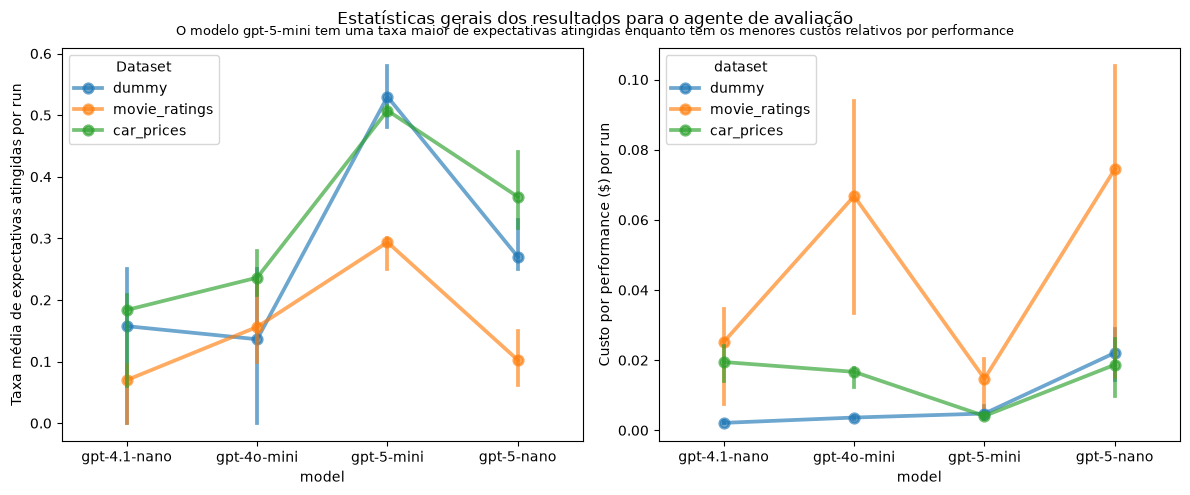

In [127]:
suptitle = "Estatísticas gerais dos resultados para o agente de avaliação"
title = "O modelo gpt-5-mini tem uma taxa maior de expectativas atingidas enquanto tem os menores custos relativos por performance"
plot_general_results(general_eval_results, suptitle=suptitle,title=title)

Os resultados acima mostram que o modelo *gpt-5-mini* tende a atingir melhor as expectativas estabelecidas para o passo de avaliação por dataset além de ter o melhor custo benefício no geral de acordo com o segundo gráfico. Em compensação, o modelo *gpt-5-nano* parece ter uma variabilidade maior de performance enquanto atinge custos altos relativamente.

Os gráficos acima também indicam a dificuldade relativa dos datasets, com os modelos tendendo a atingir melhores resultados de avaliação no *car_prices* seguido pelo *dummy* e, então, pelo *movie_ratings*.

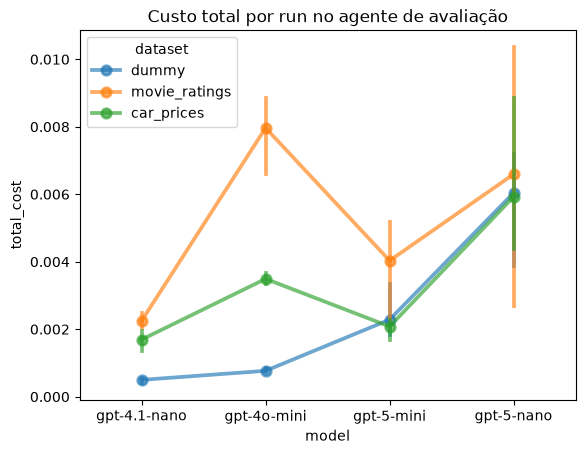

In [128]:
sns.pointplot(data=general_eval_results, y='total_cost', x='model', hue='dataset', errorbar=("pi", 50), alpha=0.65)
plt.title("Custo total por run no agente de avaliação")
plt.show()
plt.tight_layout()
plt.close()

O gráfico acima mostra que, apesar de ter os melhores resultados gerais, o *gpt-5-mini* não tem os menores custos totais. Entretanto, seus custos são sim próximos dos menores custos observados.

### 4.2 Resultados da etapa de transformação das bases

Essa seção analisa os resultados obtidos ao verificar as expectativas atingidas após a etapa de transformação e as tools utilizadas.

In [129]:
def load_transform_results() -> dict[str, pd.DataFrame]:
    RESULTS_BASE_DIR_PATH = "../src_data_readyness_agent/testing/test_results/"
    results_map = [
        {'dataset':'dummy', 'path':RESULTS_BASE_DIR_PATH + "transformation_agent_dummy_data.csv"},
        {'dataset':'movie_ratings', 'path':RESULTS_BASE_DIR_PATH + "transformation_agent_movie_ratings_data.csv"},
        {'dataset':'car_prices', 'path':RESULTS_BASE_DIR_PATH + "transformation_agent_car_price_data.csv"}
    ]
    result = dict()
    for dataset_result in results_map:
        curr_result = pd.read_csv(dataset_result['path'])
        result[dataset_result['dataset']] = curr_result 
    return result

In [130]:
transformation_results = load_transform_results()
for dataset_name, df in transformation_results.items():
    print(dataset_name, "results shape:", df.shape)

dummy results shape: (32, 24)
movie_ratings results shape: (32, 52)
car_prices results shape: (32, 35)


In [131]:
transformation_results['dummy'].head().T

,0,1,2,3,4
metragem_dtype_is_numeric,True,True,True,True,True
classe_dtype_is_numeric,False,False,False,False,False
especial_dtype_is_numeric,False,False,True,True,False
data_abertura_dtype_is_datetime,False,False,False,False,False
faturamento_dtype_is_numeric,True,True,True,True,True
qt_mesas_dtype_is_numeric,True,True,True,True,True
Loja_dtype_is_string,True,True,True,True,True
metragem_doesnt_has_nulls,True,True,True,True,True
especial_doesnt_has_nulls,True,False,True,True,True
especial_cardinality_is_3,False,False,False,False,False


In [132]:
general_transformation_results = get_general_results(transformation_results)

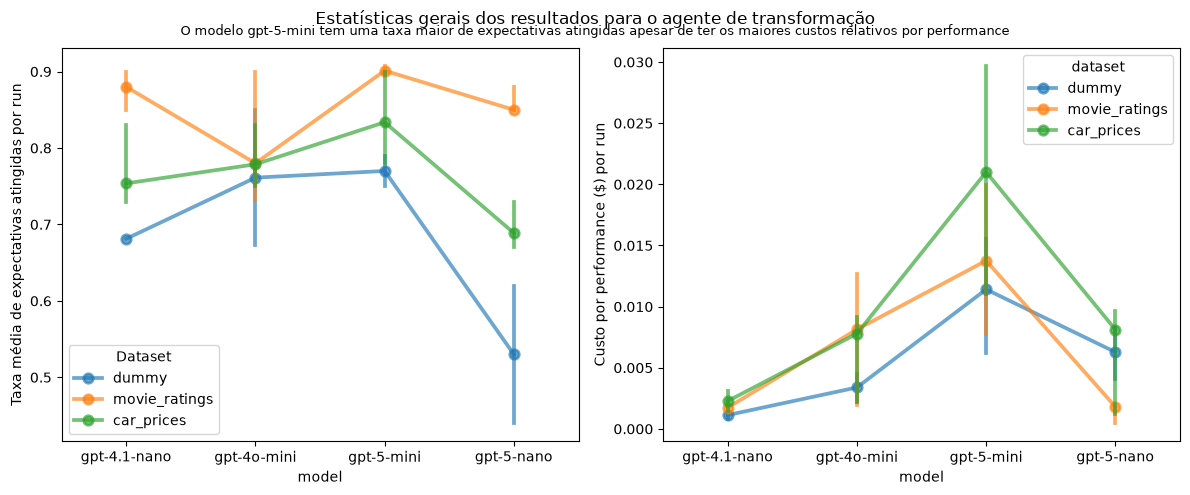

In [133]:
suptitle = "Estatísticas gerais dos resultados para o agente de transformação"
title = "O modelo gpt-5-mini tem uma taxa maior de expectativas atingidas apesar de ter os maiores custos relativos por performance"
plot_general_results(general_transformation_results, suptitle=suptitle,title=title)

Os gráficos acima mostram que a tarefa de transformação parece ser mais fácil, no geral, quando comparado com a tarefa de avaliação de acordo com as altas taxas de expectativas atingidas. Essa noção pode ser devido a algumas questões. 

Primeiro, os modelos tinham mais iterações permitidas na etapa de transformação do que na de avaliação. Isso foi baseado no entendimento de que um objetivo definido na etapa de avaliação pode requerer mais de uma ação na etapa de transformação para ser completado. Por exemplo, para transformar uma coluna string em numérico, pode ser necessário remover sufixos dos seus valores para, então, realizar a converção. Dessa forma, ao limitar relativamente a quantidade de avaliações que poderiam ser feitas, também limita-se as chances de atingir uma expectativa pré-estabelecida naquela etapa. Além disso, a maior quantidade de ações realizadas pelo agente de transformação leva a uma maior necessidade de chamadas de ferramentas o que aumenta o custo dessa etapa.

Segundo, enquanto o agente de avaliação não recebeu nenhuma instrução específica do que checar, o agente de transformação recebeu as instruções produzidas pelo agente de avaliação. Dessa forma, a etapa de avaliação pode ser caracterizada como uma etapa de exploração enquanto a etapa de transformação se caracteriza como etapa de seguir instruções mais explícitas e raciocínio para concluir esses objetivos. Essa segunda é, portanto, uma etapa em que o modelo utilizado tem objetivos mais específicos além de mais informações sobre a base.

Sobre a dificuldade relativa das bases, o *movie_ratings* agora foi o dataset em que os modelos melhor performaram. Enquanto isso, as bases *dummy* e *car_prices* trocaram de posição relativa de dificuldade com o *dummy* sendo mais difícil.

Sobre a performance dos modelos, o *gpt-5-mini* novamente parece ser o que atinge a melhor performance entre os modelos, entretanto, dessa vez, ele possui os maiores custos relativos. 

Dessa forma, surge a questão de se, para realizar a tarefa como um todo, é suficiente ter um bom modelo na etapa de avaliação ou se é necessário que ambos os agentes tenham modelos com capacidades melhores.


In [234]:
target_cols = ['avg_acc', 'total_cost', 'model', 'run_id', 'dataset']
merged_results = general_eval_results[target_cols].merge(general_transformation_results[target_cols], 
                                                         on =['run_id', 'dataset'], 
                                                         suffixes=("_eval", "_transform"))
merged_results['config_name'] = merged_results['model_eval'] + "/" + merged_results['model_transform']
merged_results.head()

,avg_acc_eval,total_cost_eval,model_eval,run_id,dataset,avg_acc_transform,total_cost_transform,model_transform,config_name
0,0.42,0.000256,gpt-4.1-nano,1,dummy,0.69,0.001450,gpt-4.1-nano,gpt-4.1-nano/gpt-4.1-nano
1,0.25,0.000509,gpt-4.1-nano,2,dummy,0.54,0.000793,gpt-4.1-nano,gpt-4.1-nano/gpt-4.1-nano
2,0.17,0.000433,gpt-4.1-nano,3,dummy,0.69,0.000828,gpt-4.1-nano,gpt-4.1-nano/gpt-4.1-nano
3,0.25,0.000523,gpt-4.1-nano,4,dummy,0.77,0.000562,gpt-4.1-nano,gpt-4.1-nano/gpt-4.1-nano
4,0.17,0.000572,gpt-4.1-nano,29,dummy,0.77,0.001800,gpt-5-nano,gpt-4.1-nano/gpt-5-nano


In [239]:
def plot_config_results(results:pd.DataFrame, suptitle:str, title:str, before_col:str, after_col:str, target_col_name:str, highlight_configs:list[str]=None):
    merged_cp = pd.DataFrame()
    moments = list()
    target_values = list()
    datasets = list()
    config_names = list()
    for idx, row in results.iterrows():
        moments.extend(['evaluation', 'transformation'])
        datasets.extend([row['dataset']]*2)
        target_values.extend([row[before_col], row[after_col]])
        config_names.extend([row['config_name']] * 2)
    
    merged_cp['moment'] = moments
    merged_cp['dataset'] = datasets
    merged_cp[target_col_name] = target_values
    merged_cp['config_name'] = config_names

    cmap = plt.get_cmap("tab10")

    base_configs = sorted(list(set(config_names)))

    color_map = {
        config: cmap(i)
        for i, config in enumerate(base_configs)
    }
    if highlight_configs is None:
        highlight_configs = base_configs

    blank_color = 'silver'
    actual_colors = {
        config: color_map[config] if config in highlight_configs else blank_color
        for config in color_map
    }
    hue_order = [config for config in color_map if config not in highlight_configs] + list(highlight_configs)
    fig = sns.catplot(data=merged_cp, col='dataset', hue='config_name', x='moment', y=target_col_name, kind='point',
                palette=actual_colors, alpha=0.8, hue_order=hue_order)
    fig.figure.set_size_inches(12, 5)
    fig.legend.set_title("Eval model/Transformation model")
    fig.legend.set_bbox_to_anchor((1.02, 0.5))
    fig.legend.set_loc("center left")
    fig.figure.suptitle(suptitle, fontsize=14, y=0.98)
    fig.figure.text(0.5, 0.9, title, ha='center', fontsize=10)
    fig.figure.subplots_adjust(top=0.8)
    plt.tight_layout()
    plt.show()
    plt.close()

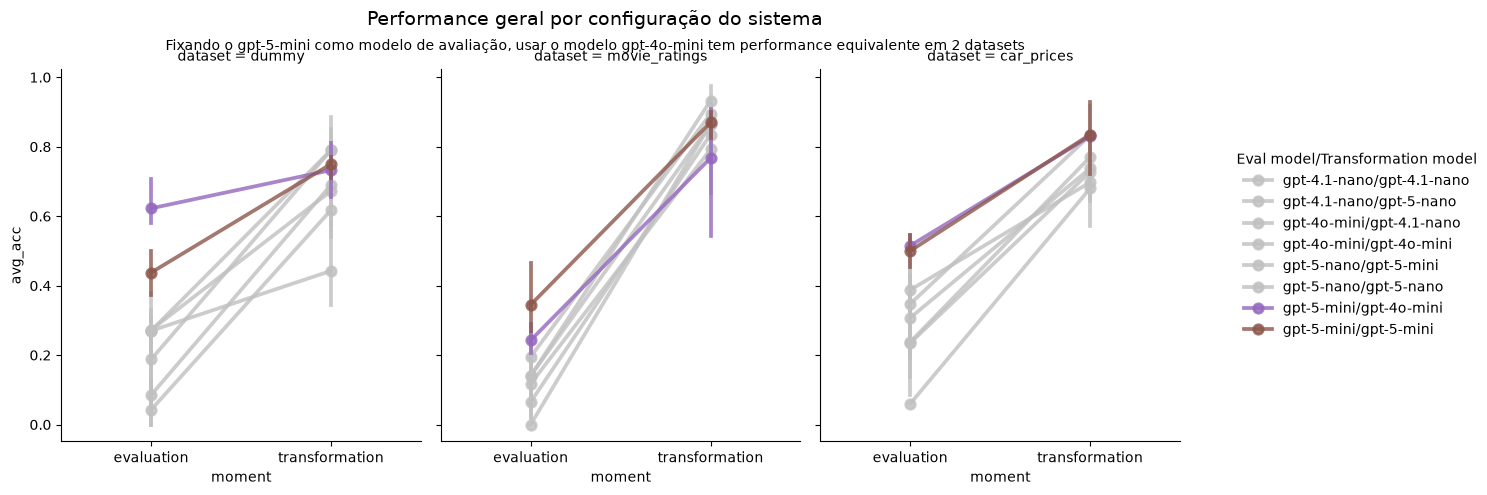

In [240]:
suptitle = "Performance geral por configuração do sistema"
title = "Fixando o gpt-5-mini como modelo de avaliação, usar o modelo gpt-4o-mini tem performance equivalente em 2 datasets"
plot_config_results(merged_results, suptitle, title, before_col='avg_acc_eval', after_col='avg_acc_transform', 
                    target_col_name='avg_acc', highlight_configs=['gpt-5-mini/gpt-4o-mini', 'gpt-5-mini/gpt-5-mini'])

Os gráficos acima mostram que, fixando o modelo *gpt-5-mini* como sendo o modelo do agente de avaliação (já que ele atingiu as melhores performances gerais), usar do modelo *gpt-4o-mini* como modelo do agente de transformação conseguiu resultados equivalentes em 2 dos 3 datasets.

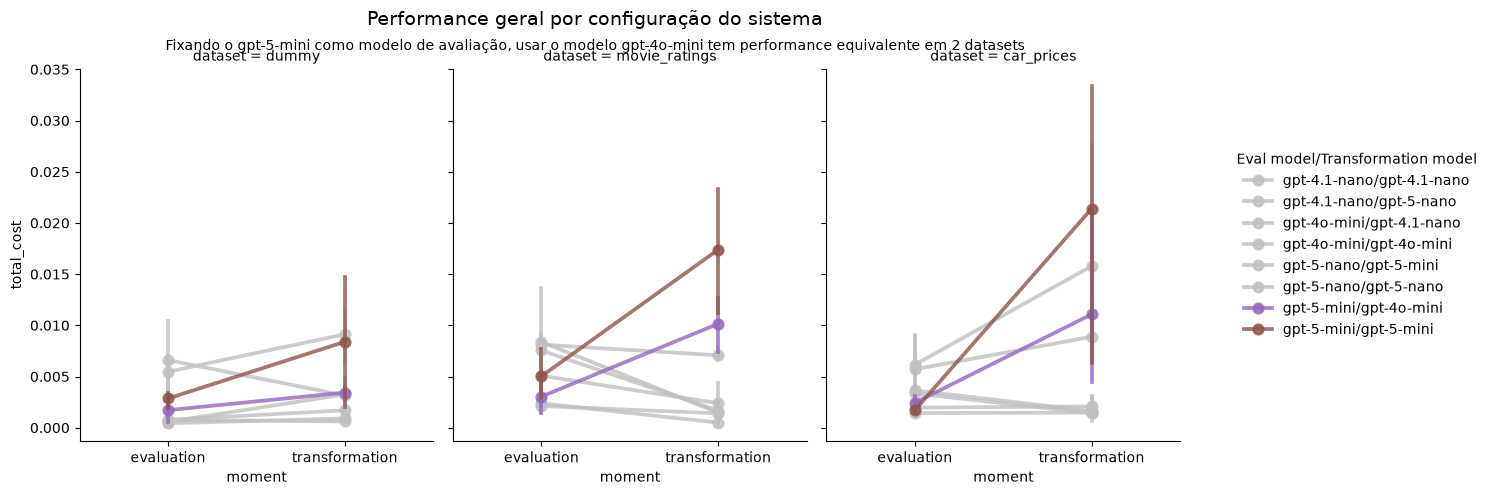

In [241]:
suptitle = "Performance geral por configuração do sistema"
title = "Fixando o gpt-5-mini como modelo de avaliação, usar o modelo gpt-4o-mini tem performance equivalente em 2 datasets"
plot_config_results(merged_results, suptitle, title, before_col='total_cost_eval', after_col='total_cost_transform', 
                    target_col_name='total_cost',highlight_configs=['gpt-5-mini/gpt-4o-mini', 'gpt-5-mini/gpt-5-mini'])

Os gráficos acima mostram que, ao comparar os custos de usar modelos diferentes no agente de transformação, o modelo *gpt-4o-mini* tende a gastar menos do que o *gpt-5-mini*.

Levando em consideração o custo benefício total, pode-se concluir que a configuração *gpt-5-mini* como agente de avaliação e *gpt-4o-mini* como agente de transformação é a melhor encontrada.